# Sampling an Ellipsoid uniformly vs sampling uniform circle and stretching

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import ecc_vr as vr 

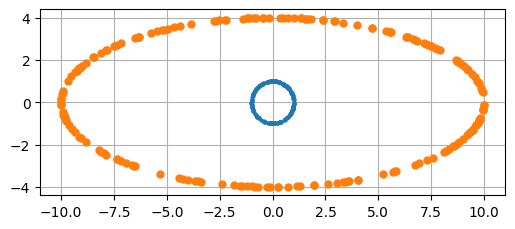

In [2]:

dim = 2
r=1
a = 10
b = 4
A = np.array([[1/a**2, 0],
               [0, 1/b**2]])
L = np.linalg.cholesky(A).T 

x = np.random.normal(0,1,(200,dim)) 

z = np.linalg.norm(x, axis=1) 
z = z.reshape(-1,1).repeat(x.shape[1], axis=1) 
y = x/z * r #uniform on the unit circle
y_new = np.linalg.inv(L) @ y.T #not uniform on ellipse boundary in arc-length sense

plt.figure(figsize=(6,6))
plt.plot(y[:,0],y[:,1], linestyle="", marker='o', markersize=2)
plt.plot(y_new.T[:,0],y_new.T[:,1], linestyle="", marker='o', markersize=5)
plt.gca().set_aspect(1)
plt.grid()

## Summary

### Why the previous code was wrong

The previous sampler did:

`g = normal sample`  
`u = g / ||g||`  
`x = stretch * u`

This is somewhat correct:

- `u = g / ||g||` is uniform on the unit sphere.
- `x = stretch * u` does put the point on the hyperellipsoid boundary, because it satisfies  
  $$
  \sum_{i=1}^d \frac{(x_i-c_i)^2}{a_i^2} = 1.
  $$

But it is **not uniform on the hyperellipsoid surface**.

The reason is that stretching a sphere into an ellipsoid does not preserve surface area evenly. Some directions get stretched more than others, so equal-probability points on the sphere turn into unequal surface density on the ellipsoid.

So the old code was:

- correct for getting points **on** the boundary
- incorrect for getting points **uniformly distributed over** that boundary

It would only be truly uniform if all stretch values were equal, which is just a sphere.

### What the corrected code does

The corrected code still starts with sphere points because that part is easy and exact:

`g = rng.normal(size=(m, d))`  
`u = g / np.linalg.norm(g, axis=1, keepdims=True)`

Then it computes a correction weight:

`weights = np.sqrt(np.sum((u / stretch)**2, axis=1))`

This weight measures how much the stretch distorts surface area in each direction.

Then it uses rejection sampling:

`keep = rng.random(m) < (weights / max_weight)`

This keeps candidate points with exactly the right probabilities to cancel out the distortion caused by stretching.

Finally, it maps the accepted points to the hyperellipsoid:

`x = center + u * stretch`

So the corrected code gives points that are:

- on the boundary
- uniform with respect to true surface area
- valid in any dimension `d`

### How `n_points` relates to the actual points in the end

In the corrected function, `n_points` is the number of **final returned points on the ellipse or hyperellipsoid boundary**.

So if you call:

`X = sample_hyperellipsoid_boundary(200, 10, 4)`

then `X` will contain exactly **200 actual boundary points**.

What happens internally is:

- the function generates a batch of candidate points
- some candidates are rejected by the correction step
- the loop keeps going until it has exactly `n_points` accepted points
- those accepted points are the ones returned in `X`

So `n_points` does **not** mean "number of raw Gaussian draws."  
It means "number of final usable points on the boundary."

In other words:

- raw proposals generated internally: usually **more than** `n_points`
- final accepted boundary points returned: **exactly** `n_points`

### What changing `n_points` does

Changing `n_points` does not change the shape of the ellipse or hyperellipsoid, and it does not change whether the method is correct.

It only changes how many sampled boundary points you end up with:

- smaller `n_points` gives a sparser point cloud
- larger `n_points` gives a denser point cloud
- larger `n_points` makes the empirical sample look closer to truly uniform

So:

- correctness comes from the correction step
- density of plotted/output points comes from `n_points`

### Why this is really a high-dimensional hyperellipsoid

If `stretch` has length $d$, then the output lives in $\mathbb{R}^d$ and satisfies

$$
\sum_{i=1}^d \frac{(x_i-c_i)^2}{a_i^2} = 1.
$$

That means:

- `stretch = [10, 4]` gives a 2D ellipse
- `stretch = [10, 4, 2]` gives a 3D ellipsoid surface
- `stretch` of length 1000 gives the boundary of a genuine 1000-dimensional hyperellipsoid


### One-sentence takeaway

The old code gave the right boundary but the wrong surface density; the corrected code adds a rejection step so the final `n_samples` returned points are exactly the actual boundary points and are truly uniform on the hyperellipsoid surface.

In [3]:
# we need to change logic to normalize -> rejection correction -> stretch

import numpy as np

def sample_hyperellipsoid_boundary(n_points, *stretch, center=None, seed=None, batch_size=500):
    """
    Uniformly sample points on the boundary of the full d-dimensional hyperellipsoid

        ((x1-c1)/a1)^2 + ((x2-c2)/a2)^2 + ... + ((xd-cd)/ad)^2 = 1

    n_samples : int
        Number of points to generate.

    *stretch : floats or one array-like
        The semi-axis lengths / stretch factors.
        Examples:
            sample_hyperellipsoid_boundary(1000, 10, 4)
            sample_hyperellipsoid_boundary(1000, 10, 4, 2, 1)
            sample_hyperellipsoid_boundary(1000, [10, 4, 2, 1])

    center : array-like of shape (d,), optional
        Center of the hyperellipsoid. Default is the origin.

    seed : int, optional
        Random seed.

    batch_size : int, optional
        Candidate points per loop. Keep this moderate for very high dimension.
    """
    rng = np.random.default_rng(seed)

    # Allow either sample_hyperellipsoid_boundary(n, 10, 4, 2)
    # or sample_hyperellipsoid_boundary(n, [10, 4, 2])
    if len(stretch) == 1 and np.ndim(stretch[0]) != 0:
        a = np.asarray(stretch[0], dtype=float)
    else:
        a = np.asarray(stretch, dtype=float)

    d = a.size

    if center is None:
        c = np.zeros(d, dtype=float)
    else:
        c = np.asarray(center, dtype=float)
        if c.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")

    X = np.empty((n_points, d), dtype=float)
    filled = 0

    # Maximum possible value of sqrt(sum((u_i / a_i)^2)) over ||u||=1
    max_weight = 1.0 / np.min(a)

    while filled < n_points:
        m = min(batch_size, max(batch_size // 4, 4 * (n_points - filled)))

        # Uniform point on the unit sphere in R^d
        g = rng.normal(size=(m, d))
        u = g / np.linalg.norm(g, axis=1, keepdims=True)

        # Rejection correction to make the final ellipsoid sample surface-uniform
        weights = np.sqrt(np.sum((u / a) ** 2, axis=1))
        keep = rng.random(m) < (weights / max_weight)

        # Stretch from sphere to hyperellipsoid
        accepted = c + u[keep] * a

        take = min(len(accepted), n_points - filled)
        X[filled:filled + take] = accepted[:take]
        filled += take

    return X


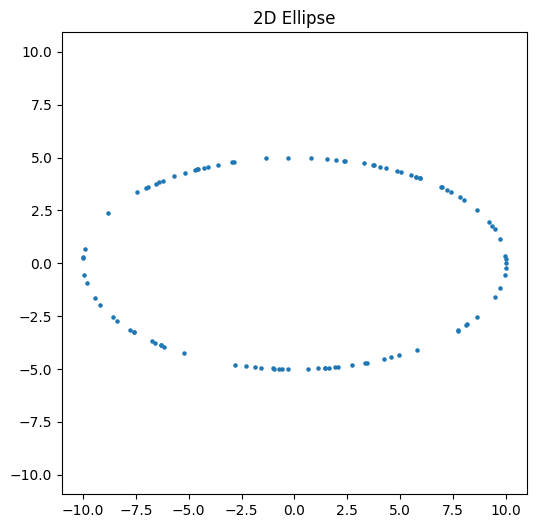

In [4]:
n_samples = 100
r1, r2 = 10, 5

X2 = sample_hyperellipsoid_boundary(n_samples, r1, r2, seed=None)

plt.figure(figsize=(6, 6))
plt.scatter(X2[:, 0], X2[:, 1], s=5)
plt.title("2D Ellipse")
plt.axis("equal")
plt.show()

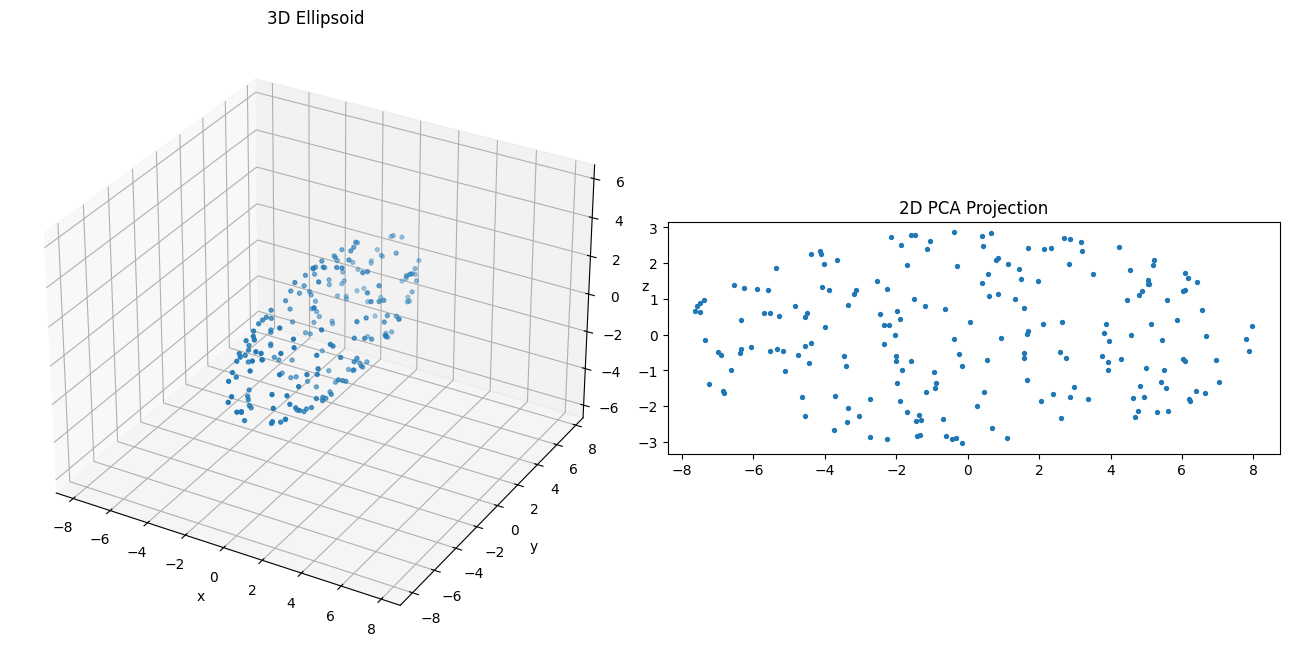

In [5]:
n_samples = 200
a, b, c = 2, 8, 3

X3 = sample_hyperellipsoid_boundary(n_samples, a, b, c, seed=None)

Y3 = vr.pca_project(X3, out_dim=2)

fig = plt.figure(figsize=(13, 8))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=8)
ax1.set_title("3D Ellipsoid")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.grid(True)
ax1.axis("equal")

ax2 = fig.add_subplot(122)
ax2.scatter(Y3[:, 0], Y3[:, 1], s=8)
ax2.set_title("2D PCA Projection")
ax2.set_aspect("equal")

plt.tight_layout()
plt.show()


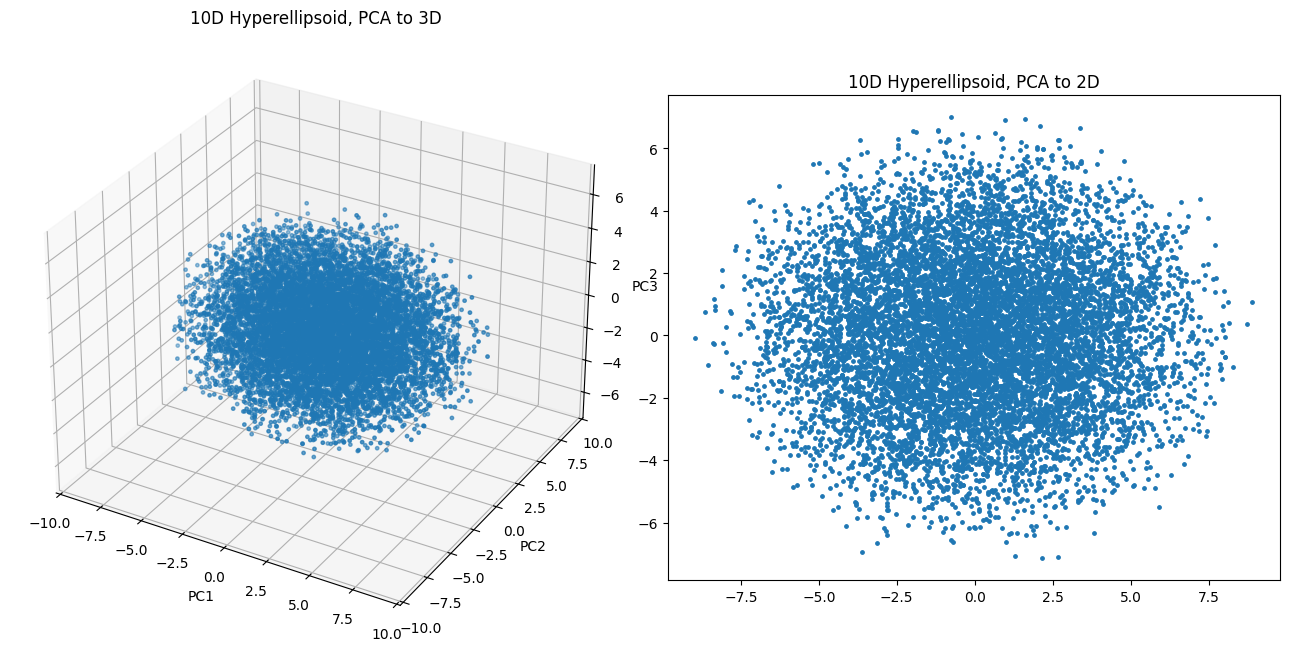

In [6]:
n_samples = 10000
stretch10 = np.array([10, 8, 7, 6, 5, 4, 3, 2.5, 2, 1.5])

X10 = sample_hyperellipsoid_boundary(n_samples, stretch10, seed=3)

Y10_2d = vr.pca_project(X10, out_dim=2)
Y10_3d = vr.pca_project(X10, out_dim=3)

fig = plt.figure(figsize=(13, 8))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(Y10_3d[:, 0], Y10_3d[:, 1], Y10_3d[:, 2], s=6)
ax1.set_title("10D Hyperellipsoid, PCA to 3D")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")
ax1.axis("equal")

ax2 = fig.add_subplot(122)
ax2.scatter(Y10_2d[:, 0], Y10_2d[:, 1], s=6)
ax2.set_title("10D Hyperellipsoid, PCA to 2D")
ax2.set_aspect("equal")
ax2.grid(False)

plt.tight_layout()
plt.show()
